In [1]:
# Task 1000 — ARIMA Forecasting

This notebook builds a leakage-safe ARIMA forecasting pipeline for:

- TSLA
- GOOGL
- BTCUSD
- ETHUSD

ARIMA is used as a short- to medium-horizon time-series benchmark.

Forecast horizons:

- 30D
- 3M
- 6M

Methodology:

1. Log-price transformation
2. Train/test split
3. Train-only stationarity and order selection
4. Calendar-aligned target construction
5. Walk-forward forecasting
6. Refit every 5 trading observations
7. Out-of-sample evaluation

SyntaxError: invalid decimal literal (3556792709.py, line 14)

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)
from statsmodels.tools.sm_exceptions import (
    ConvergenceWarning
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
PROJECT_ROOT = Path.cwd().parent

ARIMA_DATA = (
    PROJECT_ROOT
    / "data"
    / "arima"
)

RESULTS = PROJECT_ROOT / "results"

ARIMA_FORECASTS = (
    RESULTS
    / "arima_forecasts"
)

ARIMA_METRICS = (
    RESULTS
    / "arima_metrics"
)

ARIMA_FORECASTS.mkdir(
    parents=True,
    exist_ok=True
)

ARIMA_METRICS.mkdir(
    parents=True,
    exist_ok=True
)

In [4]:
assets = [
    "TSLA",
    "GOOGL",
    "BTCUSD",
    "ETHUSD"
]

arima_assets = {}

for asset in assets:

    df = pd.read_csv(
        ARIMA_DATA
        / f"{asset}_arima.csv"
    )

    df["Date"] = pd.to_datetime(
        df["Date"]
    )

    df = (
        df
        .sort_values("Date")
        .reset_index(drop=True)
    )

    arima_assets[asset] = df

In [5]:
for asset, df in arima_assets.items():

    print(
        asset,
        "|",
        df["Date"].min(),
        "→",
        df["Date"].max(),
        "| rows:",
        len(df)
    )

TSLA | 2010-06-28 00:00:00 → 2026-08-25 00:00:00 | rows: 4064
GOOGL | 2004-08-19 00:00:00 → 2026-08-25 00:00:00 | rows: 5539
BTCUSD | 2010-07-19 00:00:00 → 2026-08-26 00:00:00 | rows: 4168
ETHUSD | 2015-08-07 00:00:00 → 2026-08-25 00:00:00 | rows: 4037


In [6]:
tsla_arima = arima_assets["TSLA"].copy()

In [7]:
tsla_arima = (
    tsla_arima
    .sort_values("Date")
    .reset_index(drop=True)
)

In [8]:
split_idx = int(
    len(tsla_arima) * 0.8
)

train_df = tsla_arima.iloc[
    :split_idx
].copy()

test_df = tsla_arima.iloc[
    split_idx:
].copy()

In [9]:
print(
    "Train:",
    train_df["Date"].min(),
    "→",
    train_df["Date"].max()
)

print(
    "Test:",
    test_df["Date"].min(),
    "→",
    test_df["Date"].max()
)

print(
    "Train samples:",
    len(train_df)
)

print(
    "Test samples:",
    len(test_df)
)

Train: 2010-06-28 00:00:00 → 2023-05-26 00:00:00
Test: 2023-05-30 00:00:00 → 2026-08-25 00:00:00
Train samples: 3251
Test samples: 813


In [10]:
train_log_price = (
    train_df["Log_Price"]
    .dropna()
)

train_log_return = (
    train_df["Log_Return"]
    .dropna()
)

In [14]:
result_price = adfuller(
    train_log_price,
)

print("Train Log Price")
print("ADF Statistic:", result_price[0])
print("p-value:", result_price[1])

Train Log Price
ADF Statistic: -1.0020860770497555
p-value: 0.7525026923038256


In [13]:
result_return = adfuller(
    train_log_return
)

print("\nTrain Log Return")
print("ADF Statistic:", result_return[0])
print("p-value:", result_return[1])


Train Log Return
ADF Statistic: -58.01127693054703
p-value: 0.0


In [ ]:
### Train-Only Stationarity Test

The ADF test is performed only on the training sample to avoid
using information from the test period during model selection.

If the log-price series is non-stationary while its first
difference (log return) is stationary, first-order differencing
is sufficient.

Therefore:

d = 1

<Figure size 1000x500 with 0 Axes>

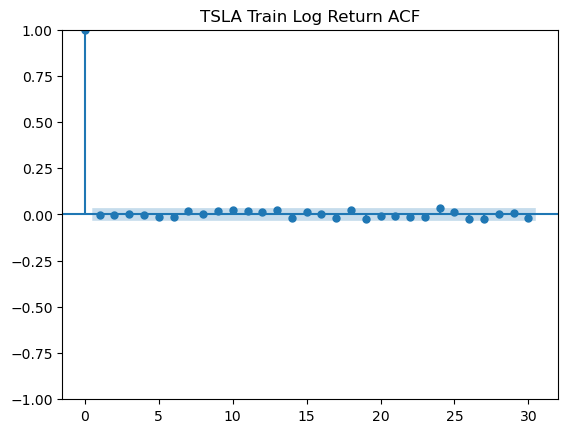

In [15]:
plt.figure(figsize=(10, 5))

plot_acf(
    train_log_return,
    lags=30
)

plt.title("TSLA Train Log Return ACF")
plt.show()

<Figure size 1000x500 with 0 Axes>

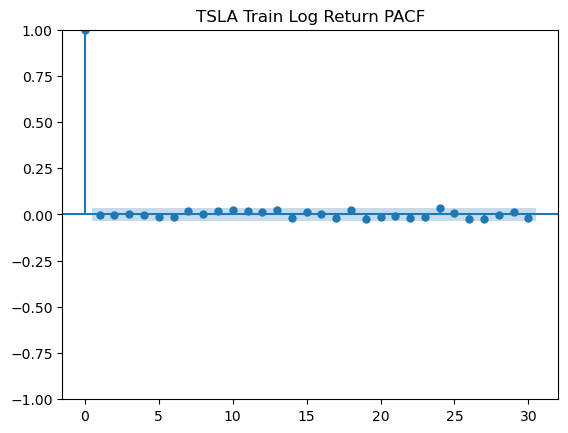

In [16]:
plt.figure(figsize=(10, 5))

plot_pacf(
    train_log_return,
    lags=30,
    method="ywm"
)

plt.title("TSLA Train Log Return PACF")
plt.show()

In [ ]:
### Train-Only ACF and PACF

The ACF and PACF are calculated using only the training sample to avoid test-set leakage.

- ACF is used as a diagnostic for potential MA structure.
- PACF is used as a diagnostic for potential AR structure.

If most lag correlations are close to zero and remain within the confidence interval, this suggests weak serial dependence and supports testing low-order ARIMA specifications.

In [17]:
candidate_orders = [
    (0, 1, 0),
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1)
]

In [18]:
comparison_results = []

for order in candidate_orders:

    model = ARIMA(
        train_log_price,
        order=order,
        trend="n"
    )

    fitted_model = model.fit()

    comparison_results.append({
        "Order": order,
        "AIC": fitted_model.aic,
        "BIC": fitted_model.bic
    })


D:\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [19]:
comparison_df = pd.DataFrame(
    comparison_results
)

comparison_df

,Order,AIC,BIC
0,"(0, 1, 0)",-12295.183215,-12289.096805
1,"(1, 1, 0)",-12293.211463,-12281.038643
2,"(0, 1, 1)",-12293.211499,-12281.038679
3,"(1, 1, 1)",-12291.183485,-12272.924255


In [ ]:
### Train-Only ARIMA Order Selection

Low-order ARIMA candidates are compared using only the training sample.

Candidate models:

- ARIMA(0,1,0)
- ARIMA(1,1,0)
- ARIMA(0,1,1)
- ARIMA(1,1,1)

AIC and BIC balance model fit and model complexity.

Lower values indicate a better in-sample trade-off.

The selected order will then be evaluated separately using out-of-sample walk-forward forecasting.

In [20]:
test_30d = test_df[
    [
        "Date",
        "Close",
        "Log_Price"
    ]
].copy()

test_30d["Target_Date"] = (
    test_30d["Date"]
    + pd.Timedelta(days=30)
)

In [21]:
future_prices = tsla_arima[
    [
        "Date",
        "Close",
        "Log_Price"
    ]
].copy()

future_prices = future_prices.rename(
    columns={
        "Date": "Future_Date",
        "Close": "Future_Close",
        "Log_Price": "Future_Log_Price"
    }
)

In [22]:
test_30d = pd.merge_asof(
    test_30d.sort_values("Target_Date"),
    future_prices.sort_values("Future_Date"),
    left_on="Target_Date",
    right_on="Future_Date",
    direction="forward"
)

In [23]:
test_30d_valid = test_30d.dropna(
    subset=[
        "Future_Date",
        "Future_Close"
    ]
).copy()

In [24]:
print(
    "Original test samples:",
    len(test_30d)
)

print(
    "Valid 30D samples:",
    len(test_30d_valid)
)

Original test samples: 813
Valid 30D samples: 791


In [25]:
test_30d_valid[
    [
        "Date",
        "Close",
        "Target_Date",
        "Future_Date",
        "Future_Close"
    ]
].head(10)

,Date,Close,Target_Date,Future_Date,Future_Close
0,2023-05-30,201.16,2023-06-29,2023-06-29,257.50
1,2023-05-31,203.93,2023-06-30,2023-06-30,261.77
2,2023-06-01,207.52,2023-07-01,2023-07-03,279.82
3,2023-06-02,213.97,2023-07-02,2023-07-03,279.82
4,2023-06-05,217.61,2023-07-05,2023-07-05,282.48
5,2023-06-06,221.31,2023-07-06,2023-07-06,276.54
6,2023-06-07,224.57,2023-07-07,2023-07-07,274.43
7,2023-06-08,234.86,2023-07-08,2023-07-10,269.61
8,2023-06-09,244.40,2023-07-09,2023-07-10,269.61
9,2023-06-12,249.83,2023-07-12,2023-07-12,271.99


In [26]:
def run_arima_walk_forward_30d(
    full_df,
    test_target_df,
    order=(0, 1, 0),
    refit_every=5
):
    rolling_results = []

    fitted_model = None
    last_model_date = None

    non_converged = 0
    failed_windows = 0
    skipped_windows = 0
    refit_count = 0

    for i in range(len(test_target_df)):

        row = test_target_df.iloc[i]

        current_date = row["Date"]
        current_close = row["Close"]
        future_date = row["Future_Date"]
        future_close = row["Future_Close"]

        # 1. Count trading observations from current date
        #    to the calendar-aligned future date
        forecast_dates = full_df[
            (full_df["Date"] > current_date)
            &
            (full_df["Date"] <= future_date)
        ]

        steps = len(forecast_dates)

        if steps == 0:
            skipped_windows += 1
            continue

        try:

            # 2. Full refit every 5 trading observations
            if fitted_model is None or i % refit_every == 0:

                history = full_df[
                    full_df["Date"] <= current_date
                ].copy()

                model = ARIMA(
                    history["Log_Price"],
                    order=order,
                    trend="n"
                )

                with warnings.catch_warnings():
                    warnings.simplefilter(
                        "ignore",
                        ConvergenceWarning
                    )

                    fitted_model = model.fit()

                refit_count += 1
                last_model_date = current_date

                converged = fitted_model.mle_retvals.get(
                    "converged",
                    True
                )

                if not converged:
                    non_converged += 1

            # 3. Between refits, append newly observed data
            else:

                new_data = full_df[
                    (full_df["Date"] > last_model_date)
                    &
                    (full_df["Date"] <= current_date)
                ]["Log_Price"]

                if len(new_data) > 0:

                    fitted_model = fitted_model.append(
                        new_data,
                        refit=False
                    )

                last_model_date = current_date

            # 4. Forecast forward to the aligned target date
            forecast_log = fitted_model.forecast(
                steps=steps
            )

            predicted_log_price = forecast_log.iloc[-1]

            # 5. Convert log price back to price
            predicted_future_price = np.exp(
                predicted_log_price
            )

            # 6. Convert to cumulative return
            predicted_return = (
                predicted_future_price
                / current_close
                - 1
            )

            actual_return = (
                future_close
                / current_close
                - 1
            )

            # 7. Store result
            rolling_results.append({
                "Date": current_date,
                "Current_Close": current_close,
                "Future_Date": future_date,
                "Forecast_Steps": steps,
                "Actual_Future_Price": future_close,
                "Predicted_Future_Price": predicted_future_price,
                "Actual_Return": actual_return,
                "Predicted_Return": predicted_return
            })

        except Exception as e:

            failed_windows += 1

            print(
                f"Failed on {current_date}: {e}"
            )

    prediction_df = pd.DataFrame(
        rolling_results
    )

    diagnostics = {
        "Forecasts": len(prediction_df),
        "Refit_Count": refit_count,
        "Non_Converged": non_converged,
        "Skipped_Windows": skipped_windows,
        "Failed_Windows": failed_windows
    }

    return prediction_df, diagnostics

In [27]:
tsla_arima_30d_predictions, tsla_arima_30d_diagnostics = (
    run_arima_walk_forward_30d(
        full_df=tsla_arima,
        test_target_df=test_30d_valid,
        order=(0, 1, 0),
        refit_every=5
    )
)

In [28]:
tsla_arima_30d_diagnostics

{'Forecasts': 791,
 'Refit_Count': 159,
 'Non_Converged': 15,
 'Skipped_Windows': 0,
 'Failed_Windows': 0}

In [29]:
tsla_arima_30d_predictions.head()

,Date,Current_Close,Future_Date,Forecast_Steps,Actual_Future_Price,Predicted_Future_Price,Actual_Return,Predicted_Return
0,2023-05-30,201.16,2023-06-29,21,257.50,201.16,0.280076,2.220446e-16
1,2023-05-31,203.93,2023-06-30,21,261.77,203.93,0.283627,0.000000e+00
2,2023-06-01,207.52,2023-07-03,21,279.82,207.52,0.348400,0.000000e+00
3,2023-06-02,213.97,2023-07-03,20,279.82,213.97,0.307753,8.881784e-16
4,2023-06-05,217.61,2023-07-05,20,282.48,217.61,0.298102,2.220446e-16


In [33]:
def calculate_arima_metrics(
    prediction_df,
    asset_name,
    horizon,
    model_name="ARIMA"
):
    y_true = prediction_df["Actual_Return"]
    y_pred = prediction_df["Predicted_Return"]

    # Main metrics
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    directional_accuracy = np.mean(
        np.sign(y_true.values)
        ==
        np.sign(y_pred.values)
    )

    # Zero-return baseline
    baseline_pred = np.zeros(
        len(y_true)
    )

    baseline_mae = mean_absolute_error(
        y_true,
        baseline_pred
    )

    baseline_rmse = np.sqrt(
        mean_squared_error(
            y_true,
            baseline_pred
        )
    )

    # Improvement vs baseline
    mae_improvement = (
        baseline_mae - mae
    )

    rmse_improvement = (
        baseline_rmse - rmse
    )

    # Raw metrics
    metrics_raw = {
        "Asset": asset_name,
        "Model": model_name,
        "Horizon": horizon,
        "Samples": int(len(prediction_df)),

        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "Directional_Accuracy": float(
            directional_accuracy
        ),

        "Baseline_MAE": float(
            baseline_mae
        ),
        "Baseline_RMSE": float(
            baseline_rmse
        ),

        "MAE_Improvement_vs_Baseline": float(
            mae_improvement
        ),
        "RMSE_Improvement_vs_Baseline": float(
            rmse_improvement
        )
    }

    # Display metrics
    metrics_display = {
        "Asset": asset_name,
        "Model": model_name,
        "Horizon": horizon,
        "Samples": int(len(prediction_df)),

        "MAE_%": round(
            mae * 100,
            2
        ),

        "RMSE_%": round(
            rmse * 100,
            2
        ),

        "R2": round(
            r2,
            3
        ),

        "Directional_Accuracy_%": round(
            directional_accuracy * 100,
            2
        ),

        "Baseline_MAE_%": round(
            baseline_mae * 100,
            2
        ),

        "Baseline_RMSE_%": round(
            baseline_rmse * 100,
            2
        ),

        "MAE_Improvement_pp": round(
            mae_improvement * 100,
            2
        ),

        "RMSE_Improvement_pp": round(
            rmse_improvement * 100,
            2
        )
    }

    return metrics_raw, metrics_display

In [34]:
(
    tsla_arima_30d_metrics_raw,
    tsla_arima_30d_metrics_display
) = calculate_arima_metrics(
    prediction_df=tsla_arima_30d_predictions,
    asset_name="TSLA",
    horizon="30D"
)

In [35]:
pd.DataFrame(
    [tsla_arima_30d_metrics_display]
)

,Asset,Model,Horizon,Samples,MAE_%,RMSE_%,R2,Directional_Accuracy_%,Baseline_MAE_%,Baseline_RMSE_%,MAE_Improvement_pp,RMSE_Improvement_pp
0,TSLA,ARIMA,30D,791,12.34,16.63,-0.018,42.1,12.34,16.63,0.0,0.0


In [36]:
def create_arima_target(
    full_df,
    test_df,
    horizon
):
    horizon_map = {
        "30D": pd.Timedelta(days=30),
        "3M": pd.DateOffset(months=3),
        "6M": pd.DateOffset(months=6)
    }

    if horizon not in horizon_map:
        raise ValueError(
            f"Unsupported horizon: {horizon}"
        )

    target_df = test_df[
        [
            "Date",
            "Close",
            "Log_Price"
        ]
    ].copy()

    target_df["Target_Date"] = (
        target_df["Date"]
        + horizon_map[horizon]
    )

    future_prices = full_df[
        [
            "Date",
            "Close",
            "Log_Price"
        ]
    ].copy()

    future_prices = future_prices.rename(
        columns={
            "Date": "Future_Date",
            "Close": "Future_Close",
            "Log_Price": "Future_Log_Price"
        }
    )

    target_df = pd.merge_asof(
        target_df.sort_values("Target_Date"),
        future_prices.sort_values("Future_Date"),
        left_on="Target_Date",
        right_on="Future_Date",
        direction="forward"
    )

    target_df = target_df.dropna(
        subset=[
            "Future_Date",
            "Future_Close"
        ]
    ).copy()

    return target_df

In [37]:
def run_arima_walk_forward(
    full_df,
    test_target_df,
    order,
    refit_every=5
):
    rolling_results = []

    fitted_model = None
    last_model_date = None

    non_converged = 0
    failed_windows = 0
    skipped_windows = 0
    refit_count = 0

    for i in range(len(test_target_df)):

        row = test_target_df.iloc[i]

        current_date = row["Date"]
        current_close = row["Close"]
        future_date = row["Future_Date"]
        future_close = row["Future_Close"]

        forecast_dates = full_df[
            (full_df["Date"] > current_date)
            &
            (full_df["Date"] <= future_date)
        ]

        steps = len(forecast_dates)

        if steps == 0:
            skipped_windows += 1
            continue

        try:

            if fitted_model is None or i % refit_every == 0:

                history = full_df[
                    full_df["Date"] <= current_date
                ].copy()

                model = ARIMA(
                    history["Log_Price"],
                    order=order,
                    trend="n"
                )

                with warnings.catch_warnings():
                    warnings.simplefilter(
                        "ignore",
                        ConvergenceWarning
                    )

                    fitted_model = model.fit()

                refit_count += 1
                last_model_date = current_date

                converged = fitted_model.mle_retvals.get(
                    "converged",
                    True
                )

                if not converged:
                    non_converged += 1

            else:

                new_data = full_df[
                    (full_df["Date"] > last_model_date)
                    &
                    (full_df["Date"] <= current_date)
                ]["Log_Price"]

                if len(new_data) > 0:

                    fitted_model = fitted_model.append(
                        new_data,
                        refit=False
                    )

                last_model_date = current_date

            forecast_log = fitted_model.forecast(
                steps=steps
            )

            predicted_log_price = (
                forecast_log.iloc[-1]
            )

            predicted_future_price = np.exp(
                predicted_log_price
            )

            predicted_return = (
                predicted_future_price
                / current_close
                - 1
            )

            actual_return = (
                future_close
                / current_close
                - 1
            )

            rolling_results.append({
                "Date": current_date,
                "Current_Close": current_close,
                "Future_Date": future_date,
                "Forecast_Steps": steps,
                "Actual_Future_Price": future_close,
                "Predicted_Future_Price": predicted_future_price,
                "Actual_Return": actual_return,
                "Predicted_Return": predicted_return
            })

        except Exception as e:

            failed_windows += 1

            print(
                f"Failed on {current_date}: {e}"
            )

    prediction_df = pd.DataFrame(
        rolling_results
    )

    diagnostics = {
        "Forecasts": len(prediction_df),
        "Refit_Count": refit_count,
        "Non_Converged": non_converged,
        "Skipped_Windows": skipped_windows,
        "Failed_Windows": failed_windows
    }

    return prediction_df, diagnostics

In [38]:
tsla_horizons = [
    "30D",
    "3M",
    "6M"
]

TSLA_ORDER = (0, 1, 0)

tsla_arima_predictions = {}
tsla_metrics_raw = []
tsla_metrics_display = []
tsla_diagnostics = {}

In [39]:
for horizon in tsla_horizons:

    print(
        f"Running TSLA ARIMA {horizon}..."
    )

    # 1. Build calendar-aligned target
    target_df = create_arima_target(
        full_df=tsla_arima,
        test_df=test_df,
        horizon=horizon
    )

    # 2. Walk-forward forecast
    prediction_df, diagnostics = (
        run_arima_walk_forward(
            full_df=tsla_arima,
            test_target_df=target_df,
            order=TSLA_ORDER,
            refit_every=5
        )
    )

    # 3. Metrics
    metrics_raw, metrics_display = (
        calculate_arima_metrics(
            prediction_df=prediction_df,
            asset_name="TSLA",
            horizon=horizon,
            model_name="ARIMA"
        )
    )

    # 4. Save in memory
    tsla_arima_predictions[
        horizon
    ] = prediction_df

    tsla_metrics_raw.append(
        metrics_raw
    )

    tsla_metrics_display.append(
        metrics_display
    )

    tsla_diagnostics[
        horizon
    ] = diagnostics

    print(
        horizon,
        "completed:",
        len(prediction_df),
        "forecasts"
    )

Running TSLA ARIMA 30D...
30D completed: 791 forecasts
Running TSLA ARIMA 3M...
Failed on 2026-04-01 00:00:00: Given `endog` does not have an index that extends the index of the model.
Failed on 2026-04-02 00:00:00: Given `endog` does not have an index that extends the index of the model.
Failed on 2026-04-06 00:00:00: Given `endog` does not have an index that extends the index of the model.
3M completed: 746 forecasts
Running TSLA ARIMA 6M...
Failed on 2024-06-03 00:00:00: Given `endog` does not have an index that extends the index of the model.
Failed on 2024-09-03 00:00:00: Given `endog` does not have an index that extends the index of the model.
Failed on 2024-09-04 00:00:00: Given `endog` does not have an index that extends the index of the model.
Failed on 2024-09-05 00:00:00: Given `endog` does not have an index that extends the index of the model.
6M completed: 684 forecasts


In [40]:
tsla_metrics_raw_df = pd.DataFrame(
    tsla_metrics_raw
)

tsla_metrics_display_df = pd.DataFrame(
    tsla_metrics_display
)

tsla_metrics_display_df

,Asset,Model,Horizon,Samples,MAE_%,RMSE_%,R2,Directional_Accuracy_%,Baseline_MAE_%,Baseline_RMSE_%,MAE_Improvement_pp,RMSE_Improvement_pp
0,TSLA,ARIMA,30D,791,12.34,16.63,-0.018,42.10,12.34,16.63,0.00,0.0
1,TSLA,ARIMA,3M,746,22.03,29.80,-0.064,40.75,22.03,29.81,0.01,0.0
2,TSLA,ARIMA,6M,684,31.20,42.07,-0.132,40.06,31.20,42.07,-0.00,0.0


In [42]:
TSLA_ARIMA_FORECASTS = (
    ARIMA_FORECASTS
    / "TSLA"
)

TSLA_ARIMA_FORECASTS.mkdir(
    parents=True,
    exist_ok=True
)

In [43]:
for horizon, prediction_df in tsla_arima_predictions.items():

    prediction_df.to_csv(
        TSLA_ARIMA_FORECASTS
        / f"TSLA_ARIMA_{horizon}_predictions.csv",
        index=False
    )

In [44]:
TSLA_ARIMA_METRICS = (
    ARIMA_METRICS
    / "TSLA"
)

TSLA_ARIMA_METRICS.mkdir(
    parents=True,
    exist_ok=True
)

In [46]:
tsla_metrics_raw_df.to_csv(
    TSLA_ARIMA_METRICS
    / "TSLA_ARIMA_metrics_raw.csv",
    index=False
)

tsla_metrics_display_df.to_csv(
    TSLA_ARIMA_METRICS
    / "TSLA_ARIMA_metrics_display.csv",
    index=False
)


In [ ]:
For TSLA, ARIMA(0,1,0) behaves effectively as a random-walk benchmark across 30D, 3M and 6M horizons. Out-of-sample MAE and RMSE are almost identical to the zero-return baseline, while R² remains slightly negative and directional accuracy stays near 40%. This suggests limited exploitable linear time-series structure in TSLA returns over these horizons.